# Imports

In [4]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor
from functools import partial
from sklearn.cluster import KMeans

In [6]:
PLOT_COLORS = ("#1f77b4", "#ff7f0e", "#2ca02c", "#AA4A44", "#CBC3E3")
FONT_SIZES = {"small": 18, "medium": 24, "large": 28}

matplotlib.rcParams.update(
    {
        "figure.figsize": (16, 10),
        "figure.titlesize": FONT_SIZES["large"],
        "font.size": FONT_SIZES["small"],
        "axes.labelsize": FONT_SIZES["medium"],
        "axes.titlesize": FONT_SIZES["medium"],
        "xtick.labelsize": FONT_SIZES["small"],
        "ytick.labelsize": FONT_SIZES["small"],
        "legend.fontsize": FONT_SIZES["small"],
    }
)

# Data Loading & Processing

In [7]:
@dataclass(frozen=True)
class Config:
    root: Path
    rate_map: dict
    test_plan: dict
    phy_rates: dict
    kernels: tuple
    iterations: int

    @property
    def rates(self) -> tuple:
        return tuple(self.test_plan.keys())

    @property
    def conditions(self) -> list[tuple]:
        return [
            (r, bw, delay, i)
            for r, cases in self.test_plan.items()
            for bw, delay in cases
            for i in range(1, self.iterations + 1)
        ]

    def get_rate_name(self, rate: int) -> str:
        return self.rate_map.get(rate, f"Rate{rate}")

    def base(self, rate, bw, delay, iteration):
        return f"rate{rate}_bw{bw}_delay{delay}_iter{iteration}"

    def raw_path(self, kernel, rate, bw, delay, iteration):
        return self.root / kernel / "raw" / f"{self.base(rate, bw, delay, iteration)}.json"

    def debug_log_path(self, kernel, rate, bw, delay):
        return self.root / kernel / "logs" / f"rate{rate}_bw{bw}_delay{delay}.log"

    def ack_rate_path(self, kernel, rate, bw, delay, iteration):
        return self.root / kernel / "ack_rate" / f"{self.base(rate, bw, delay, iteration)}.log"


_RATE_MAP = {
    67: "HT20-SGI-MCS3",
    71: "HT20-SGI-MCS7",
    195: "HT40-SGI-MCS3",
    199: "HT40-SGI-MCS7",
}
_PHY_RATES = {
    67: 28.9,
    71: 72.2,
    195: 60.0,
    199: 150.0,
}
_TEST_PLAN = {
    67:  [("nolim", "nodelay")],
    71:  [("nolim", "nodelay")],
    195: [("nolim", "nodelay")],
    199: [("nolim", "nodelay")],
}
# _KERNELS = ("default", "tcpaad_50")
_KERNELS = ("default", "tcpaad_20", "tcpaad_30", "tcpaad_50")

# dmesg streaming active during test
config = Config(
    root=Path("../results/router_test_dmesg/").resolve(),
    rate_map=_RATE_MAP, phy_rates=_PHY_RATES,
    test_plan=_TEST_PLAN, kernels=_KERNELS, iterations=5,
)

# no dmesg — clean throughput numbers
config_nodmesg = Config(
    root=Path("../results/router_test/").resolve(),
    rate_map=_RATE_MAP, phy_rates=_PHY_RATES,
    test_plan=_TEST_PLAN, kernels=_KERNELS, iterations=5,
)

print("dmesg root   :", config.root, config.root.exists())
print("nodmesg root :", config_nodmesg.root, config_nodmesg.root.exists())
print(f"Conditions   : {len(config.conditions)}")


dmesg root   : /home/nyrik/temp/experiment/results/router_test_dmesg False
nodmesg root : /home/nyrik/temp/experiment/results/router_test False
Conditions   : 20


In [4]:
perf_rows = []
for cfg, run_label in [(config, "dmesg"), (config_nodmesg, "nodmesg")]:
    for kernel in cfg.kernels:
        for rate, bw, delay, iteration in cfg.conditions:
            jf = cfg.raw_path(kernel, rate, bw, delay, iteration)
            if not jf.exists():
                continue
            with open(jf) as f:
                d = json.load(f)
            try:
                sender = d["end"]["streams"][0]["sender"]
            except (KeyError, IndexError):
                continue
            perf_rows.append({
                "kernel": kernel,
                "run": run_label,
                "rate": rate,
                "rate_name": cfg.get_rate_name(rate),
                "bw": bw,
                "delay": delay,
                "iteration": iteration,
                "bits_per_second": sender["bits_per_second"],
                "retransmits": sender.get("retransmits", 0),
                "reorder": sender.get("reorder", 0),
                "max_snd_cwnd": sender.get("max_snd_cwnd", 0),
                "max_snd_wnd": sender.get("max_snd_wnd", 0),
                "mean_rtt_us": sender.get("mean_rtt", 0),
                "min_rtt_us": sender.get("min_rtt", 0),
                "max_rtt_us": sender.get("max_rtt", 0),
                "cpu_host": d["end"].get("cpu_utilization_percent", {}).get("host_total", 0),
            })

df = pd.DataFrame(perf_rows)
df["phy_utilization"] = df["bits_per_second"] / df["rate"].map(config.phy_rates) / 1e6 * 100
df


,kernel,run,rate,rate_name,bw,delay,iteration,bits_per_second,retransmits,reorder,max_snd_cwnd,max_snd_wnd,mean_rtt_us,min_rtt_us,max_rtt_us,cpu_host,phy_utilization
0,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,1,2.110917e+07,2,0,236024,745472,39494,24023,56460,3.516360,73.042120
1,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,2,2.124908e+07,3,0,234576,815104,41217,27894,50385,3.678427,73.526215
2,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,3,2.117903e+07,4,0,260640,1683456,35905,27362,52919,3.607960,73.283840
3,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,4,2.124725e+07,0,0,194032,187392,33558,25983,39379,3.627308,73.519903
4,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,5,2.117911e+07,0,0,270776,184320,33108,23896,44392,3.631121,73.284104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,1,1.411067e+08,833,0,362000,5302272,9931,5192,15047,70.789660,52.261752
156,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,2,1.364286e+08,884,0,401096,4396032,9786,6251,14873,67.418841,50.529109
157,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,3,1.391564e+08,767,0,414128,3932160,9623,1096,15719,68.368668,51.539394
158,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,4,1.325927e+08,690,0,351864,5335040,9897,7312,15695,67.112900,49.108405


In [5]:
ack_rows = []
for cfg, run_label in [(config, "dmesg"), (config_nodmesg, "nodmesg")]:
    for kernel in cfg.kernels:
        for rate, cases in cfg.test_plan.items():
            for bw, delay in cases:
                path = cfg.debug_log_path(kernel, rate, bw, delay)
                if not path.exists():
                    continue
                cur_iter = None
                for line in path.read_text().splitlines():
                    m = re.search(r"^--- Iteration (\d+)", line)
                    if m:
                        cur_iter = int(m.group(1))
                        continue
                    m = re.search(r"ACK count\s*:\s*(\d+)", line)
                    if m and cur_iter is not None:
                        ack_rows.append({
                            "kernel": kernel,
                            "run": run_label,
                            "rate": rate,
                            "rate_name": cfg.get_rate_name(rate),
                            "bw": bw,
                            "delay": delay,
                            "iteration": cur_iter,
                            "ack_count": int(m.group(1)),
                        })

df_acks = pd.DataFrame(ack_rows)
df_acks


,kernel,run,rate,rate_name,bw,delay,iteration,ack_count
0,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,1,13542
1,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,2,13707
2,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,3,13722
3,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,4,13537
4,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,5,13485
...,...,...,...,...,...,...,...,...
155,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,1,12687
156,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,2,13152
157,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,3,12534
158,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,4,14297


In [6]:
agg_rows = []
for cfg, run_label in [(config, "dmesg"), (config_nodmesg, "nodmesg")]:
    for kernel in cfg.kernels:
        for rate, cases in cfg.test_plan.items():
            for bw, delay in cases:
                path = cfg.debug_log_path(kernel, rate, bw, delay)
                if not path.exists():
                    continue
                cur_iter = None
                agg_count = 0
                for line in path.read_text().splitlines():
                    m = re.search(r"^--- Iteration (\d+)", line)
                    if m:
                        cur_iter = int(m.group(1))
                        agg_count = 0
                        continue
                    m = re.search(r"Average # of aggregated frames per A-MPDU:\s*([\d.]+)", line)
                    if m and cur_iter is not None:
                        agg_count += 1
                        if agg_count == 2:
                            agg_rows.append({
                                "kernel": kernel,
                                "run": run_label,
                                "rate": rate,
                                "rate_name": cfg.get_rate_name(rate),
                                "bw": bw,
                                "delay": delay,
                                "iteration": cur_iter,
                                "ampdu_avg": float(m.group(1)),
                            })

df_agg = pd.DataFrame(agg_rows)
df_agg


,kernel,run,rate,rate_name,bw,delay,iteration,ampdu_avg
0,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,1,1.6
1,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,2,1.7
2,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,3,1.7
3,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,4,1.3
4,default,dmesg,67,HT20-SGI-MCS3,nolim,nodelay,5,1.5
...,...,...,...,...,...,...,...,...
155,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,1,4.7
156,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,2,5.8
157,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,3,6.7
158,tcpaad_50,nodmesg,214,HT40-SGI-MCS14,nolim,nodelay,4,6.1


# Plots

In [7]:
KERNEL_LABELS = {"default": "Default", "tcpaad_20": "α=2.0", "tcpaad_30": "α=3.0", "tcpaad_50": "α=5.0"}
CONDITION_ORDER = ["Baseline"]
RATE_ORDER = ["HT20-SGI-MCS3", "HT20-SGI-MCS7", "HT40-SGI-MCS7", "HT40-SGI-MCS14"]
RATE_KEY = {v: k for k, v in config.rate_map.items()}

# Filter to dmesg run only for plots; nodmesg data remains in df/df_acks/df_agg
df_plot = df[df["run"] == "dmesg"].copy()
df_plot["condition"] = "Baseline"
df_acks_plot = df_acks[df_acks["run"] == "dmesg"].copy()
df_acks_plot["condition"] = "Baseline"
df_agg_plot = df_agg[df_agg["run"] == "dmesg"].copy() if not df_agg.empty else df_agg
if not df_agg_plot.empty:
    df_agg_plot["condition"] = "Baseline"

plot_dir = Path("plots")
plot_dir.mkdir(exist_ok=True)


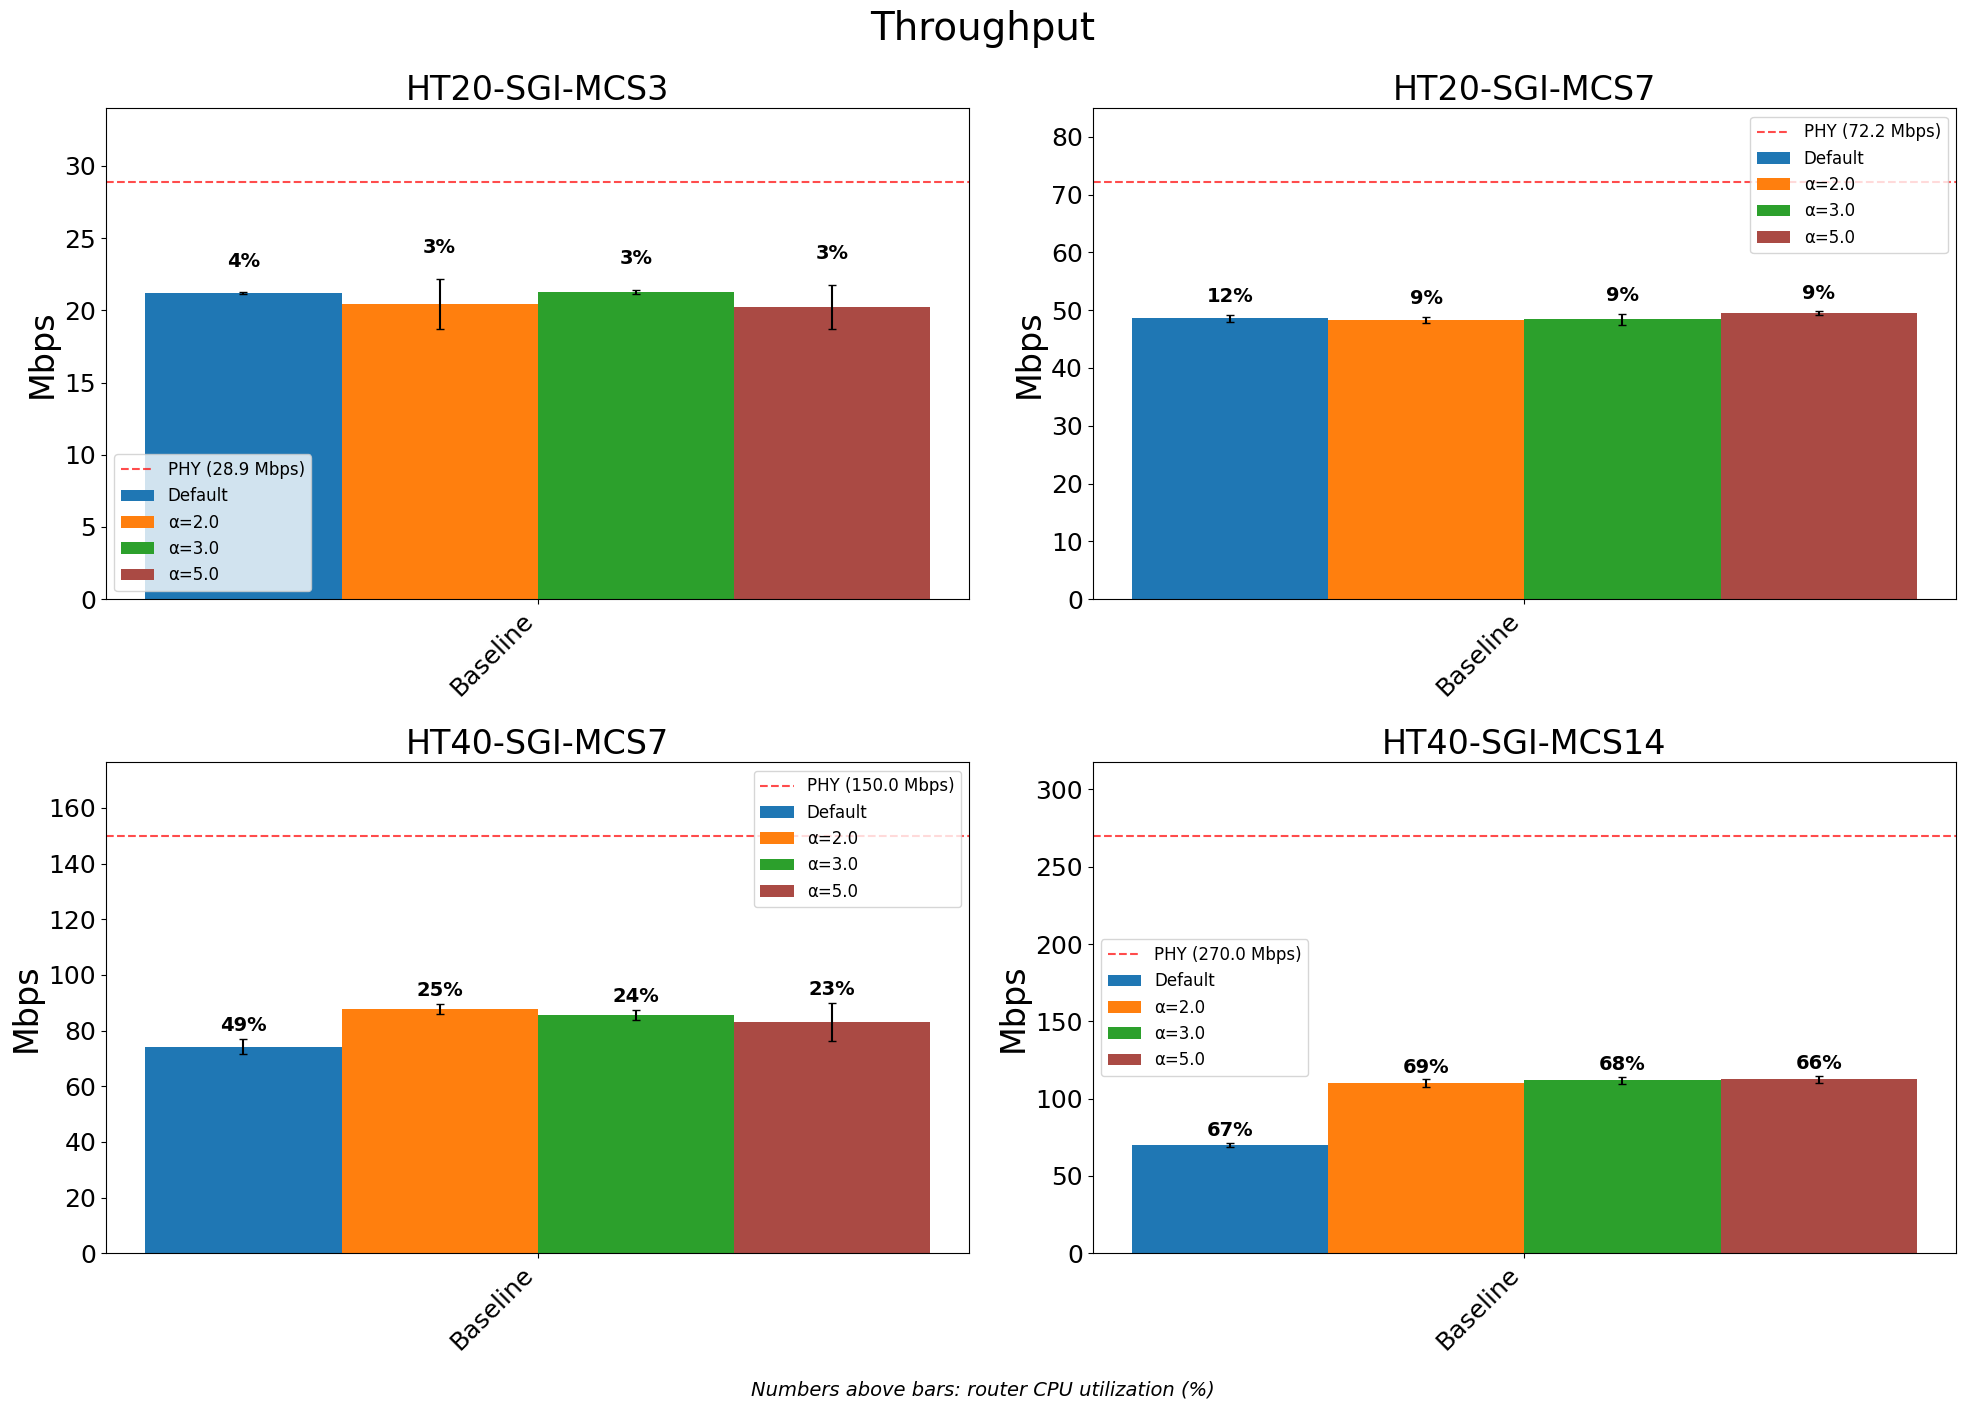

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Throughput")

for ax, rate_name in zip(axes.flat, RATE_ORDER):
    rate_df = df_plot[df_plot["rate_name"] == rate_name]
    stats = rate_df.groupby(["condition", "kernel"])["bits_per_second"].agg(["mean", "std"]).reset_index()
    cpu_stats = rate_df.groupby(["condition", "kernel"])["cpu_host"].mean().reset_index()

    x = np.arange(len(CONDITION_ORDER))
    width = 0.18

    for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
        ks = stats[stats["kernel"] == kernel].set_index("condition")
        kc = cpu_stats[cpu_stats["kernel"] == kernel].set_index("condition")
        means = [ks.loc[c, "mean"] / 1e6 if c in ks.index else 0 for c in CONDITION_ORDER]
        stds  = [ks.loc[c, "std"]  / 1e6 if c in ks.index else 0 for c in CONDITION_ORDER]
        bars = ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)
        for bar, cond in zip(bars, CONDITION_ORDER):
            if cond in kc.index:
                cpu_val = kc.loc[cond, "cpu_host"]
                std_val = ks.loc[cond, "std"] / 1e6 if cond in ks.index else 0
                top = bar.get_height() + std_val + 1.5
                ax.text(bar.get_x() + bar.get_width() / 2, top,
                        f"{cpu_val:.0f}%", ha="center", va="bottom", fontsize=14, fontweight="bold")

    phy = config.phy_rates[RATE_KEY[rate_name]]
    ax.axhline(y=phy, color="red", linestyle="--", alpha=0.7, label=f"PHY ({phy} Mbps)")

    ax.set_title(rate_name)
    ax.set_ylabel("Mbps")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
    ax.legend(fontsize=12)
    # give headroom for annotations
    ymax = ax.get_ylim()[1]
    ax.set_ylim(0, ymax * 1.12)

fig.text(0.5, -0.01, "Numbers above bars: router CPU utilization (%)", ha="center", fontsize=14, style="italic")
plt.tight_layout()
plt.savefig(plot_dir / "router_throughput.png", dpi=150, bbox_inches="tight")
plt.show()


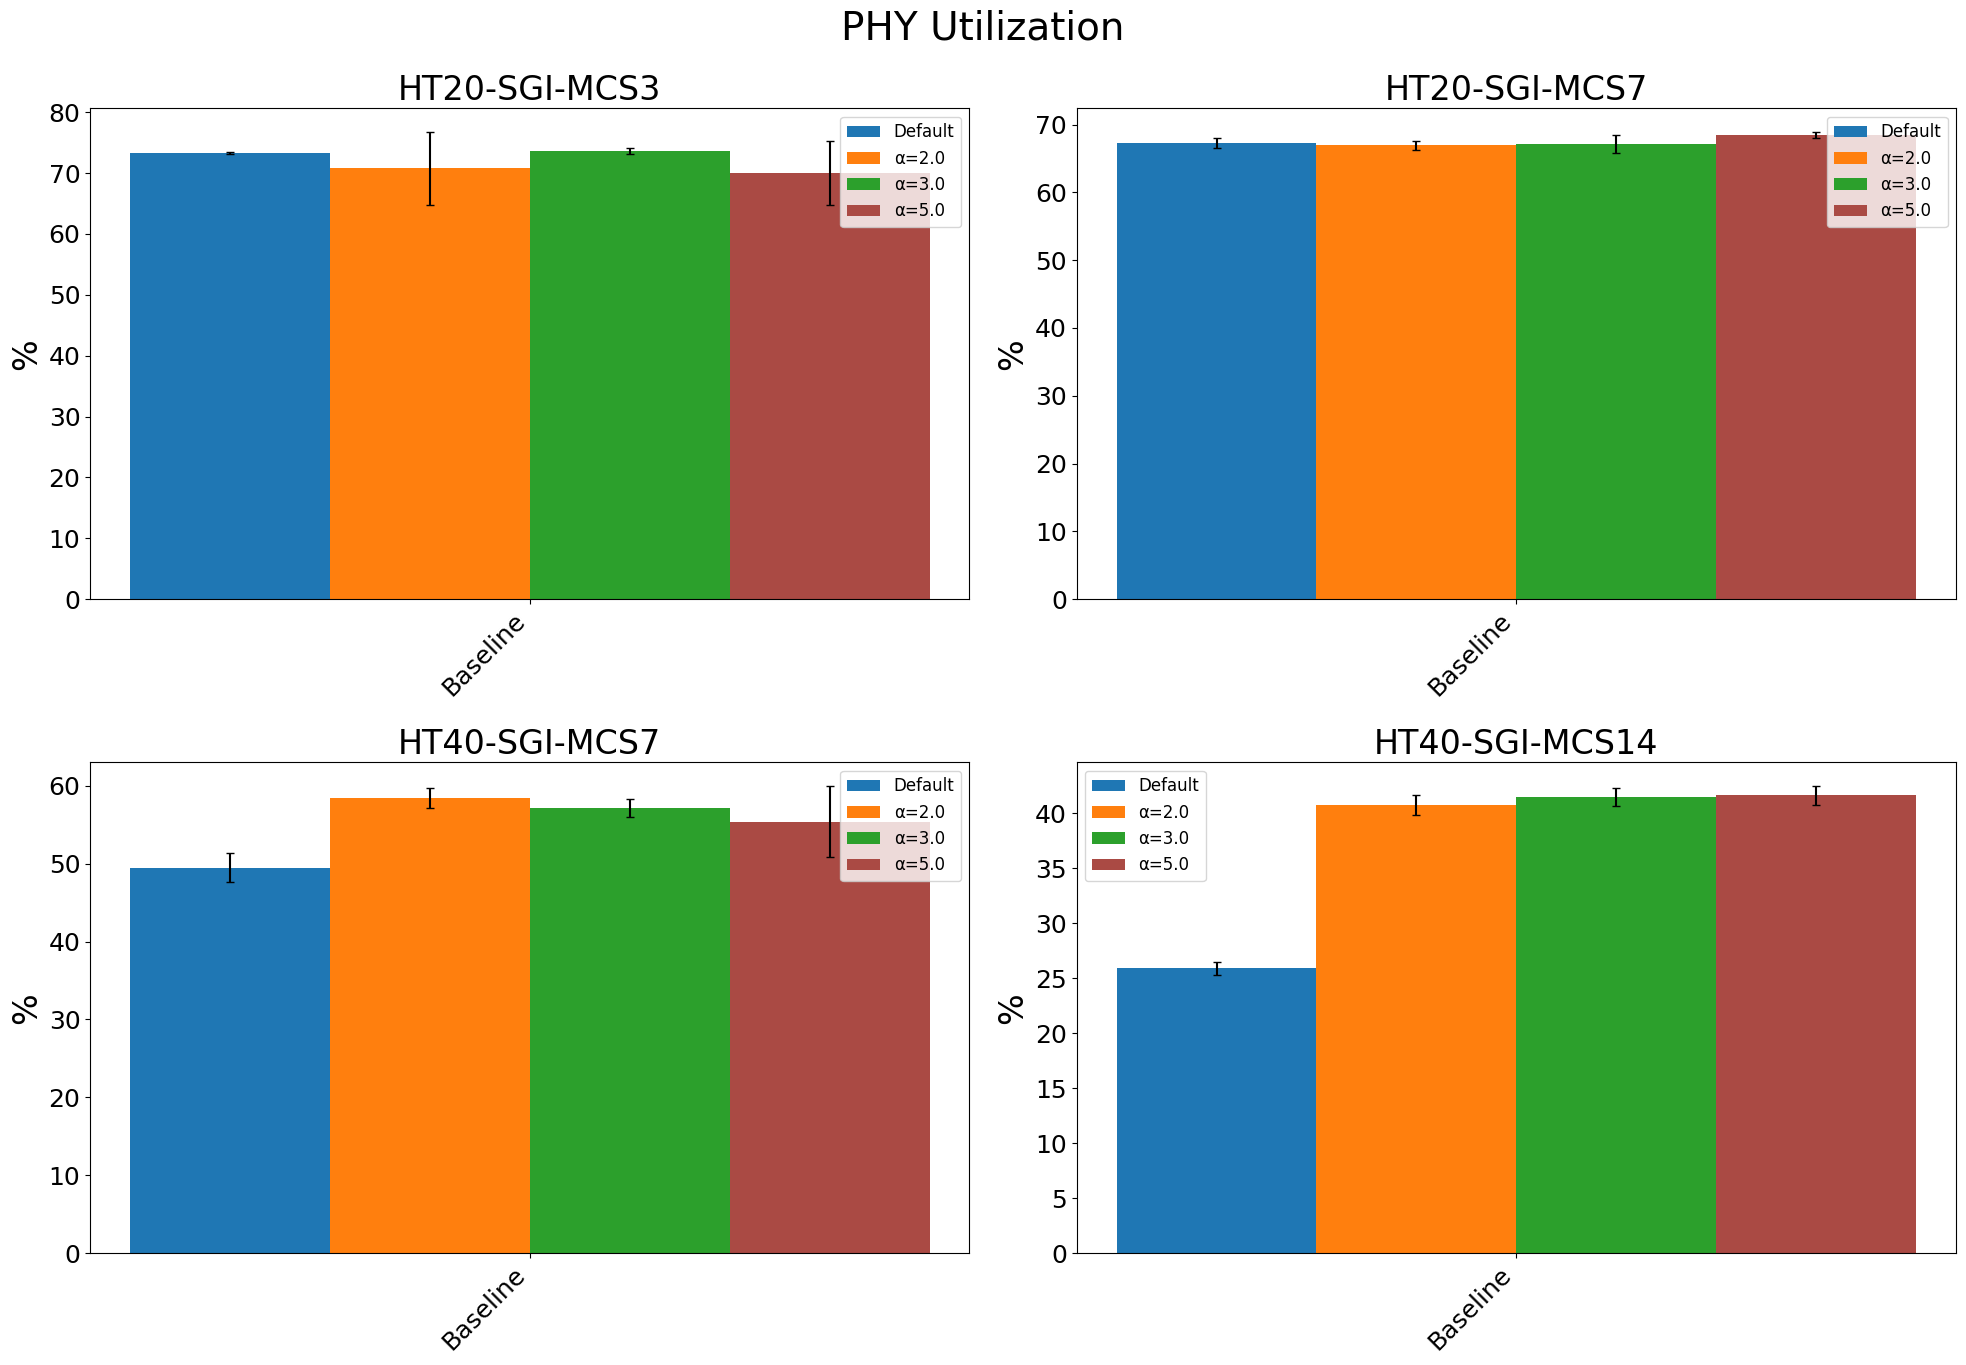

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("PHY Utilization")

for ax, rate_name in zip(axes.flat, RATE_ORDER):
    rate_df = df_plot[df_plot["rate_name"] == rate_name]
    stats = rate_df.groupby(["condition", "kernel"])["phy_utilization"].agg(["mean", "std"]).reset_index()

    x = np.arange(len(CONDITION_ORDER))
    width = 0.18

    for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
        ks = stats[stats["kernel"] == kernel].set_index("condition")
        means = [ks.loc[c, "mean"] if c in ks.index else 0 for c in CONDITION_ORDER]
        stds = [ks.loc[c, "std"] if c in ks.index else 0 for c in CONDITION_ORDER]
        ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)

    ax.set_title(rate_name)
    ax.set_ylabel("%")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(plot_dir / "router_phy_utilization.png", dpi=150, bbox_inches="tight")
plt.show()

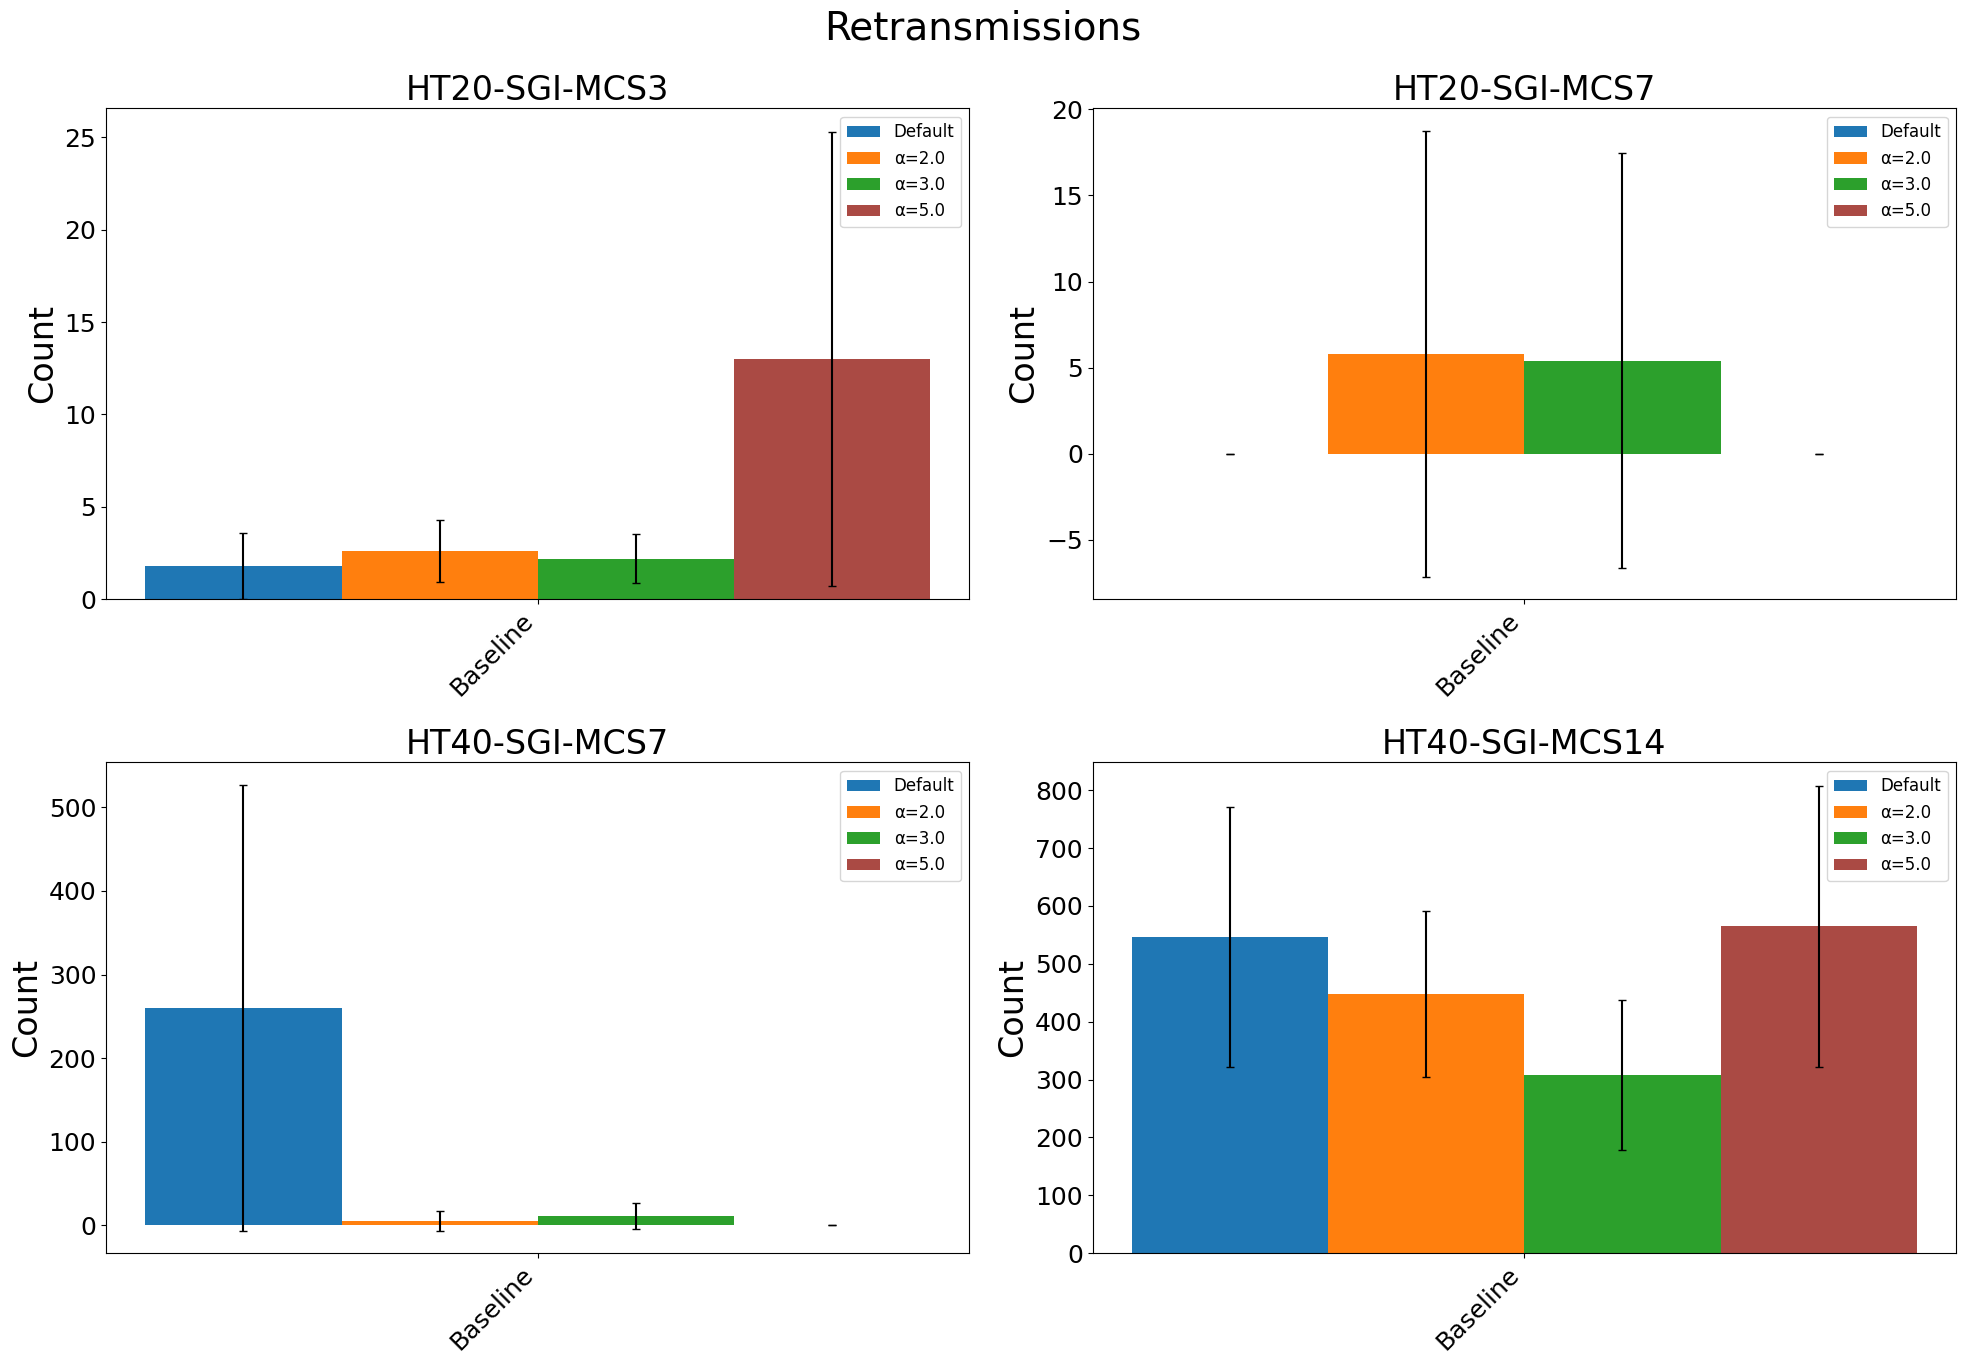

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Retransmissions")

for ax, rate_name in zip(axes.flat, RATE_ORDER):
    rate_df = df_plot[df_plot["rate_name"] == rate_name]
    stats = rate_df.groupby(["condition", "kernel"])["retransmits"].agg(["mean", "std"]).reset_index()

    x = np.arange(len(CONDITION_ORDER))
    width = 0.18

    for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
        ks = stats[stats["kernel"] == kernel].set_index("condition")
        means = [ks.loc[c, "mean"] if c in ks.index else 0 for c in CONDITION_ORDER]
        stds = [ks.loc[c, "std"] if c in ks.index else 0 for c in CONDITION_ORDER]
        ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)

    ax.set_title(rate_name)
    ax.set_ylabel("Count")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(plot_dir / "router_retransmissions.png", dpi=150, bbox_inches="tight")
plt.show()

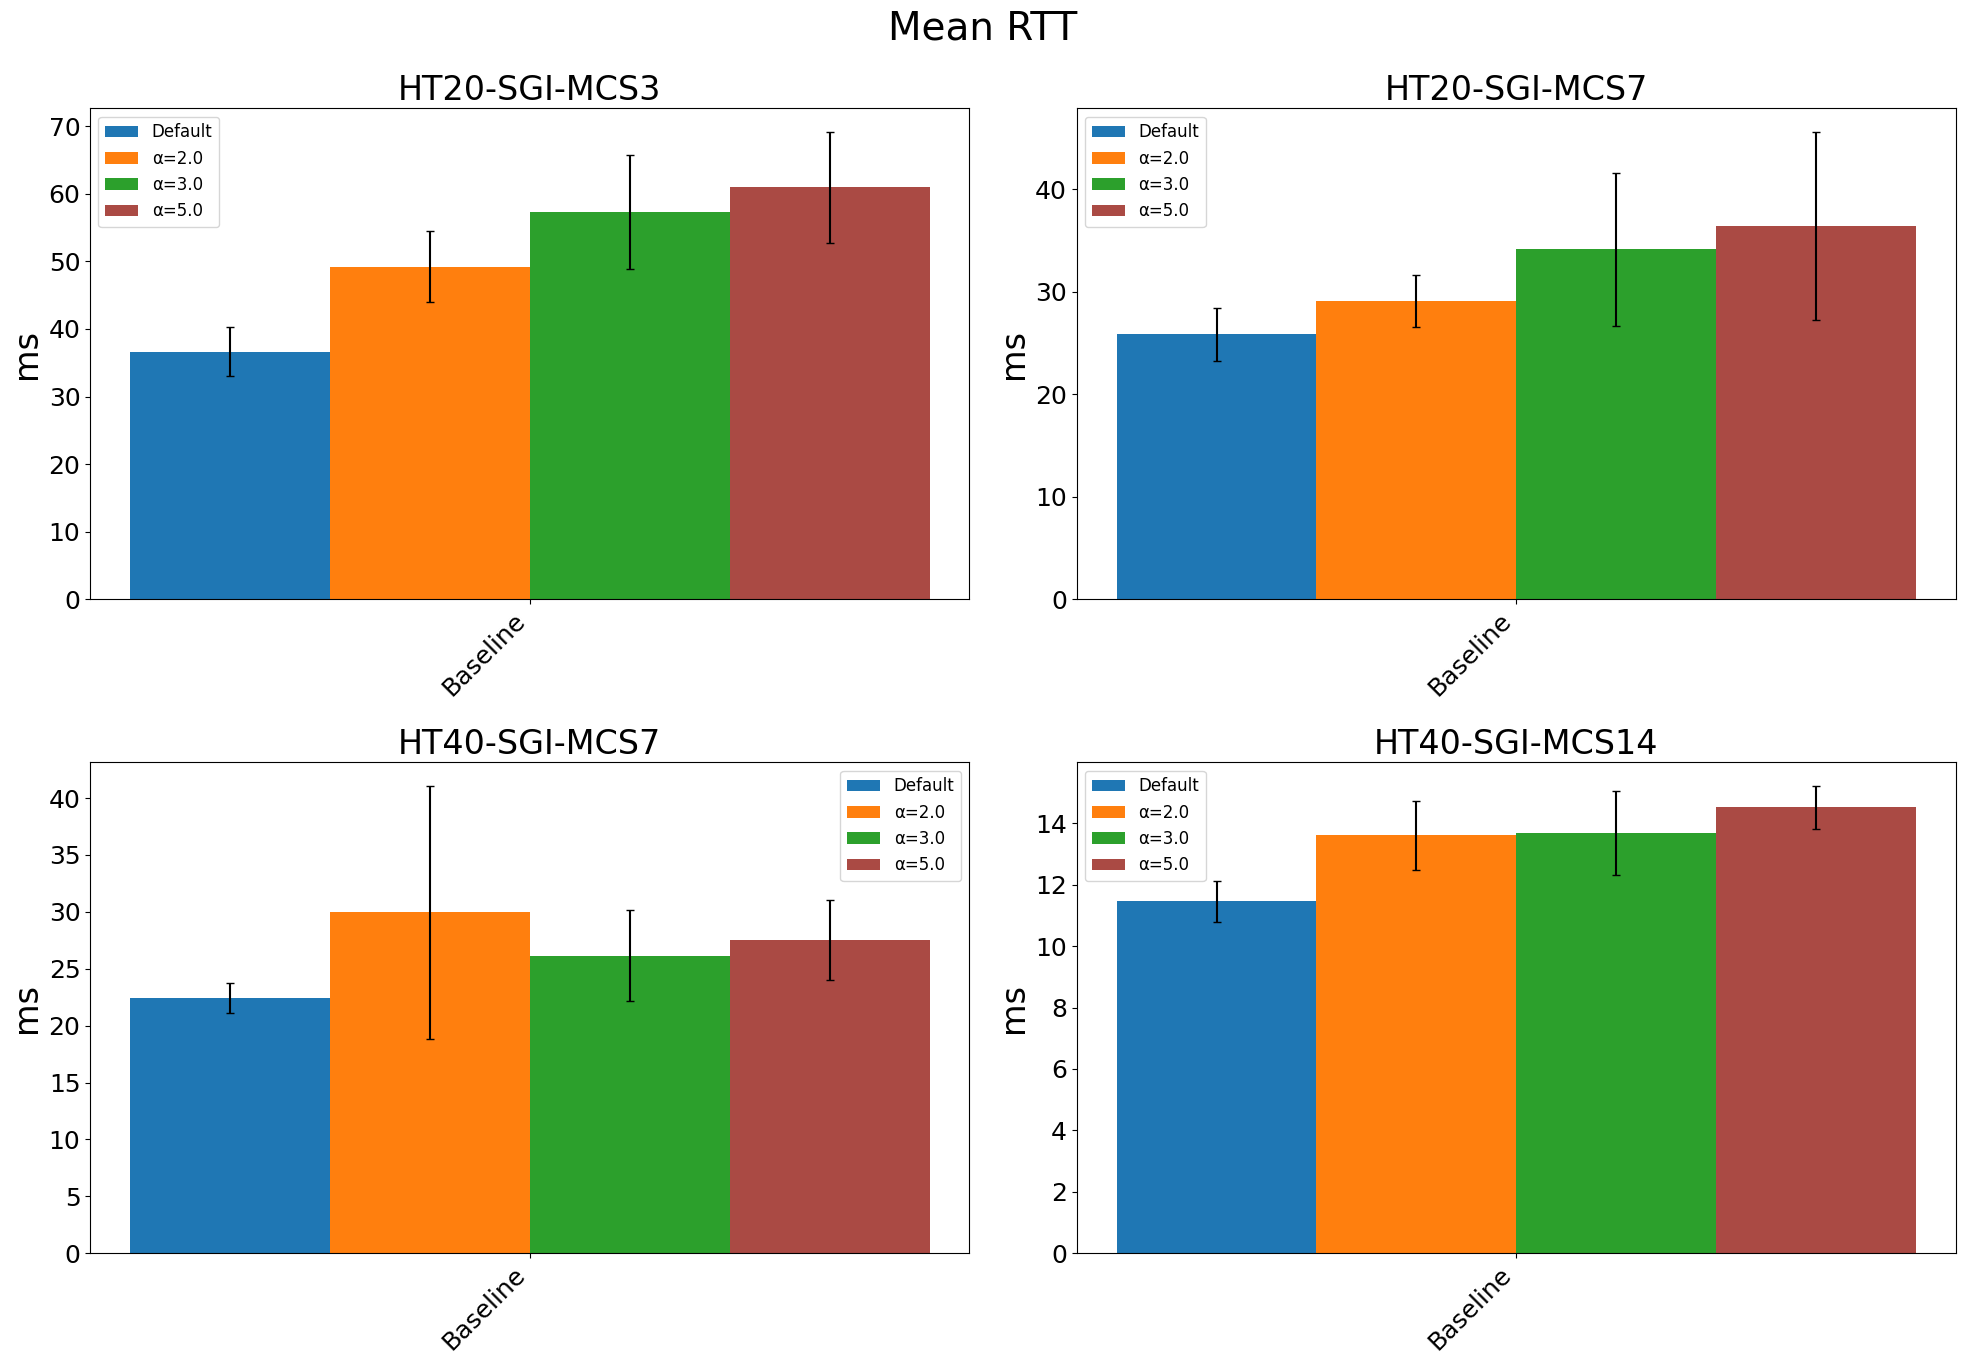

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Mean RTT")

for ax, rate_name in zip(axes.flat, RATE_ORDER):
    rate_df = df_plot[df_plot["rate_name"] == rate_name]
    stats = rate_df.groupby(["condition", "kernel"])["mean_rtt_us"].agg(["mean", "std"]).reset_index()

    x = np.arange(len(CONDITION_ORDER))
    width = 0.18

    for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
        ks = stats[stats["kernel"] == kernel].set_index("condition")
        means = [ks.loc[c, "mean"] / 1000 if c in ks.index else 0 for c in CONDITION_ORDER]
        stds = [ks.loc[c, "std"] / 1000 if c in ks.index else 0 for c in CONDITION_ORDER]
        ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)

    ax.set_title(rate_name)
    ax.set_ylabel("ms")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(plot_dir / "router_mean_rtt.png", dpi=150, bbox_inches="tight")
plt.show()

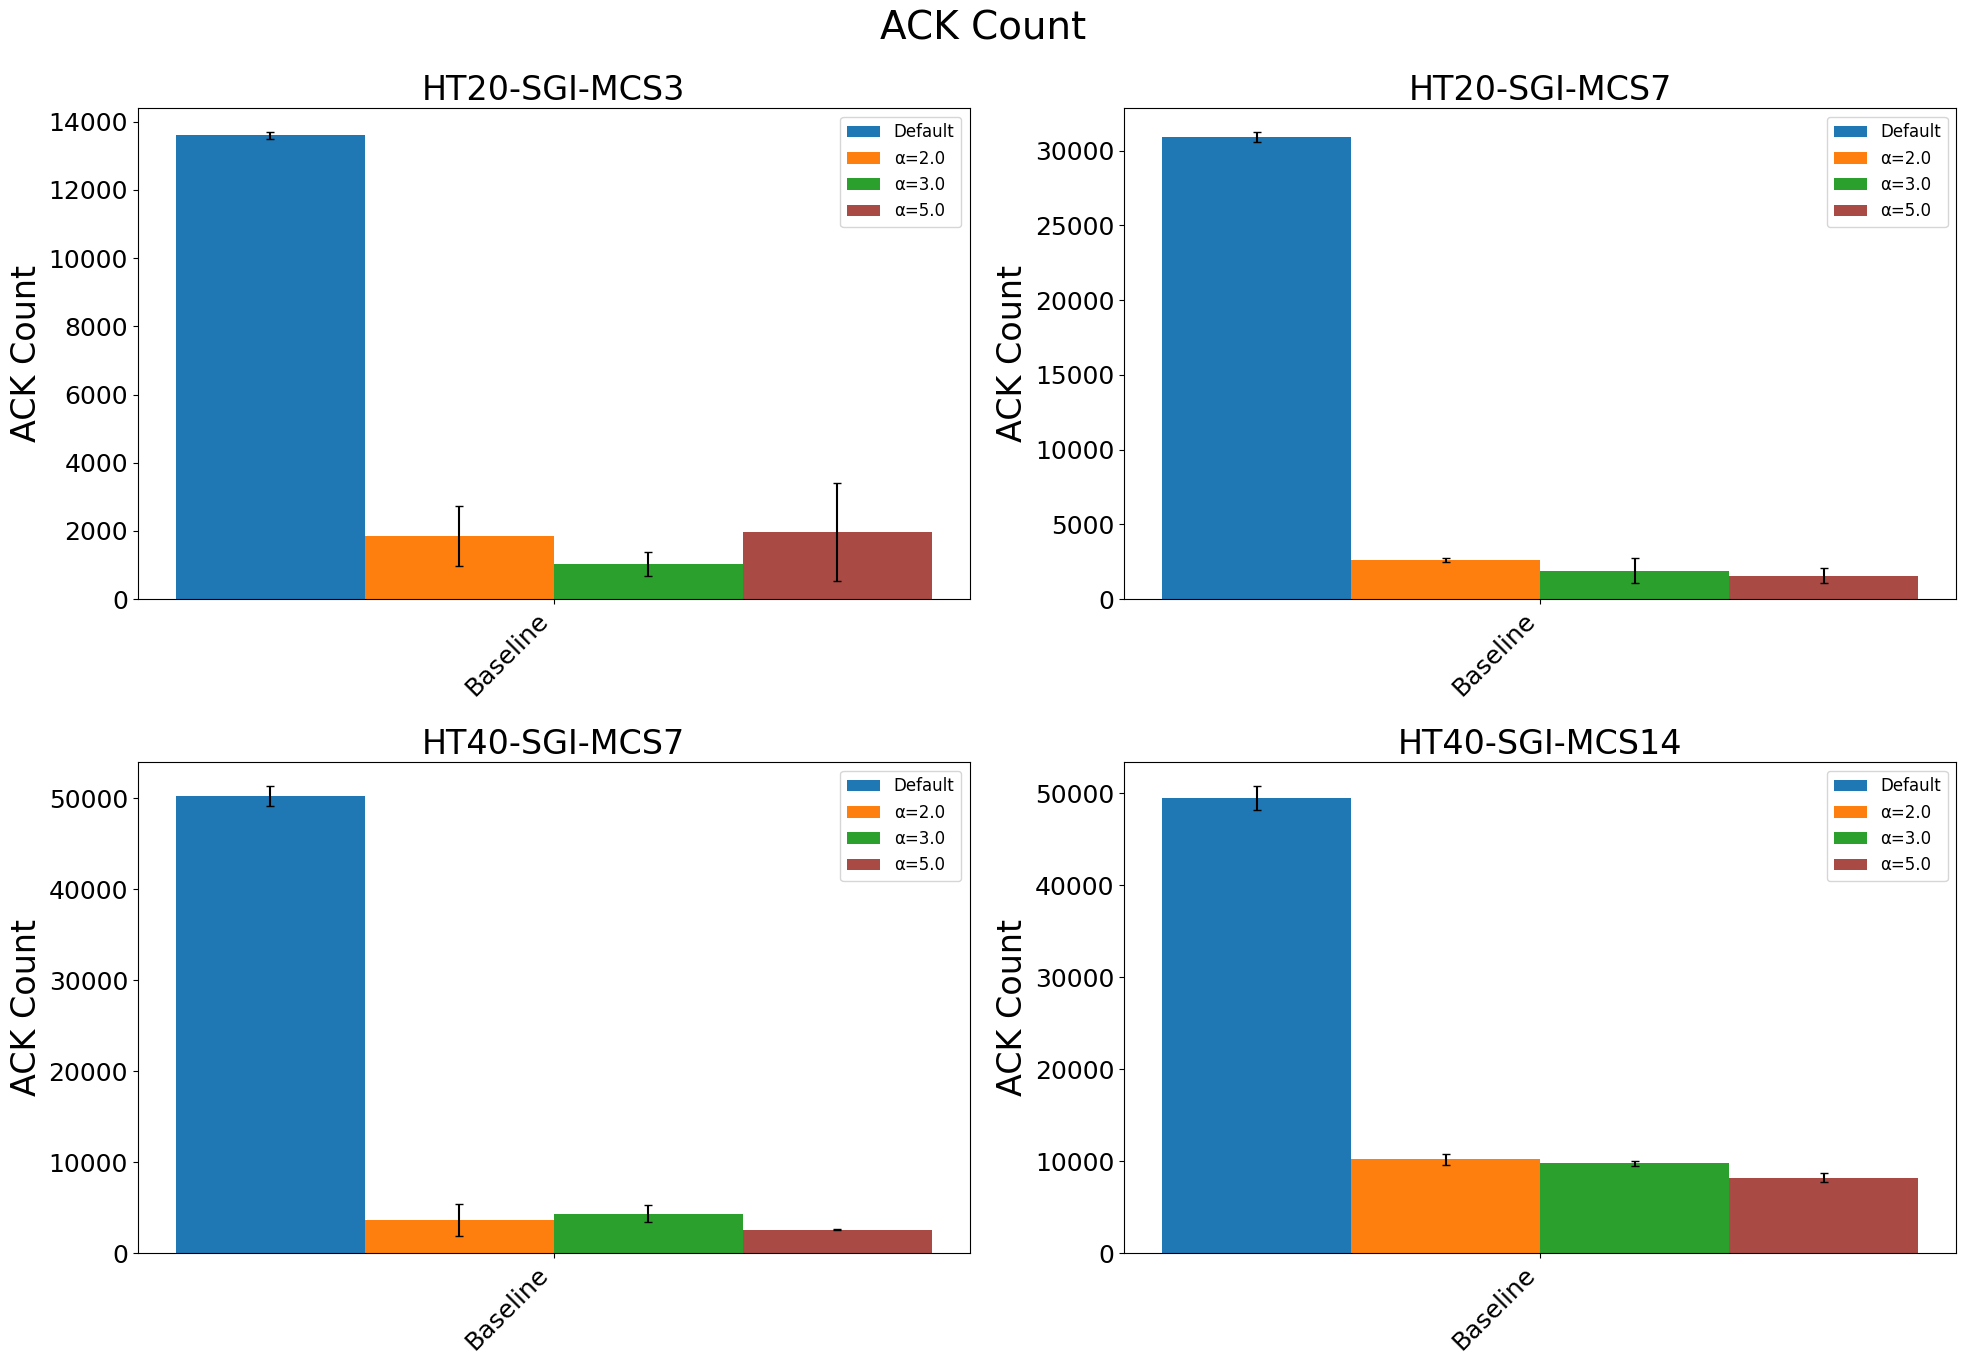

In [12]:
if not df_acks_plot.empty:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle("ACK Count")

    for ax, rate_name in zip(axes.flat, RATE_ORDER):
        rate_df = df_acks_plot[df_acks_plot["rate_name"] == rate_name]
        stats = rate_df.groupby(["condition", "kernel"])["ack_count"].agg(["mean", "std"]).reset_index()

        x = np.arange(len(CONDITION_ORDER))
        width = 0.18

        for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
            ks = stats[stats["kernel"] == kernel].set_index("condition")
            means = [ks.loc[c, "mean"] if c in ks.index else 0 for c in CONDITION_ORDER]
            stds = [ks.loc[c, "std"] if c in ks.index else 0 for c in CONDITION_ORDER]
            ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)

        ax.set_title(rate_name)
        ax.set_ylabel("ACK Count")
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
        ax.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(plot_dir / "router_ack_count.png", dpi=150, bbox_inches="tight")
    plt.show()

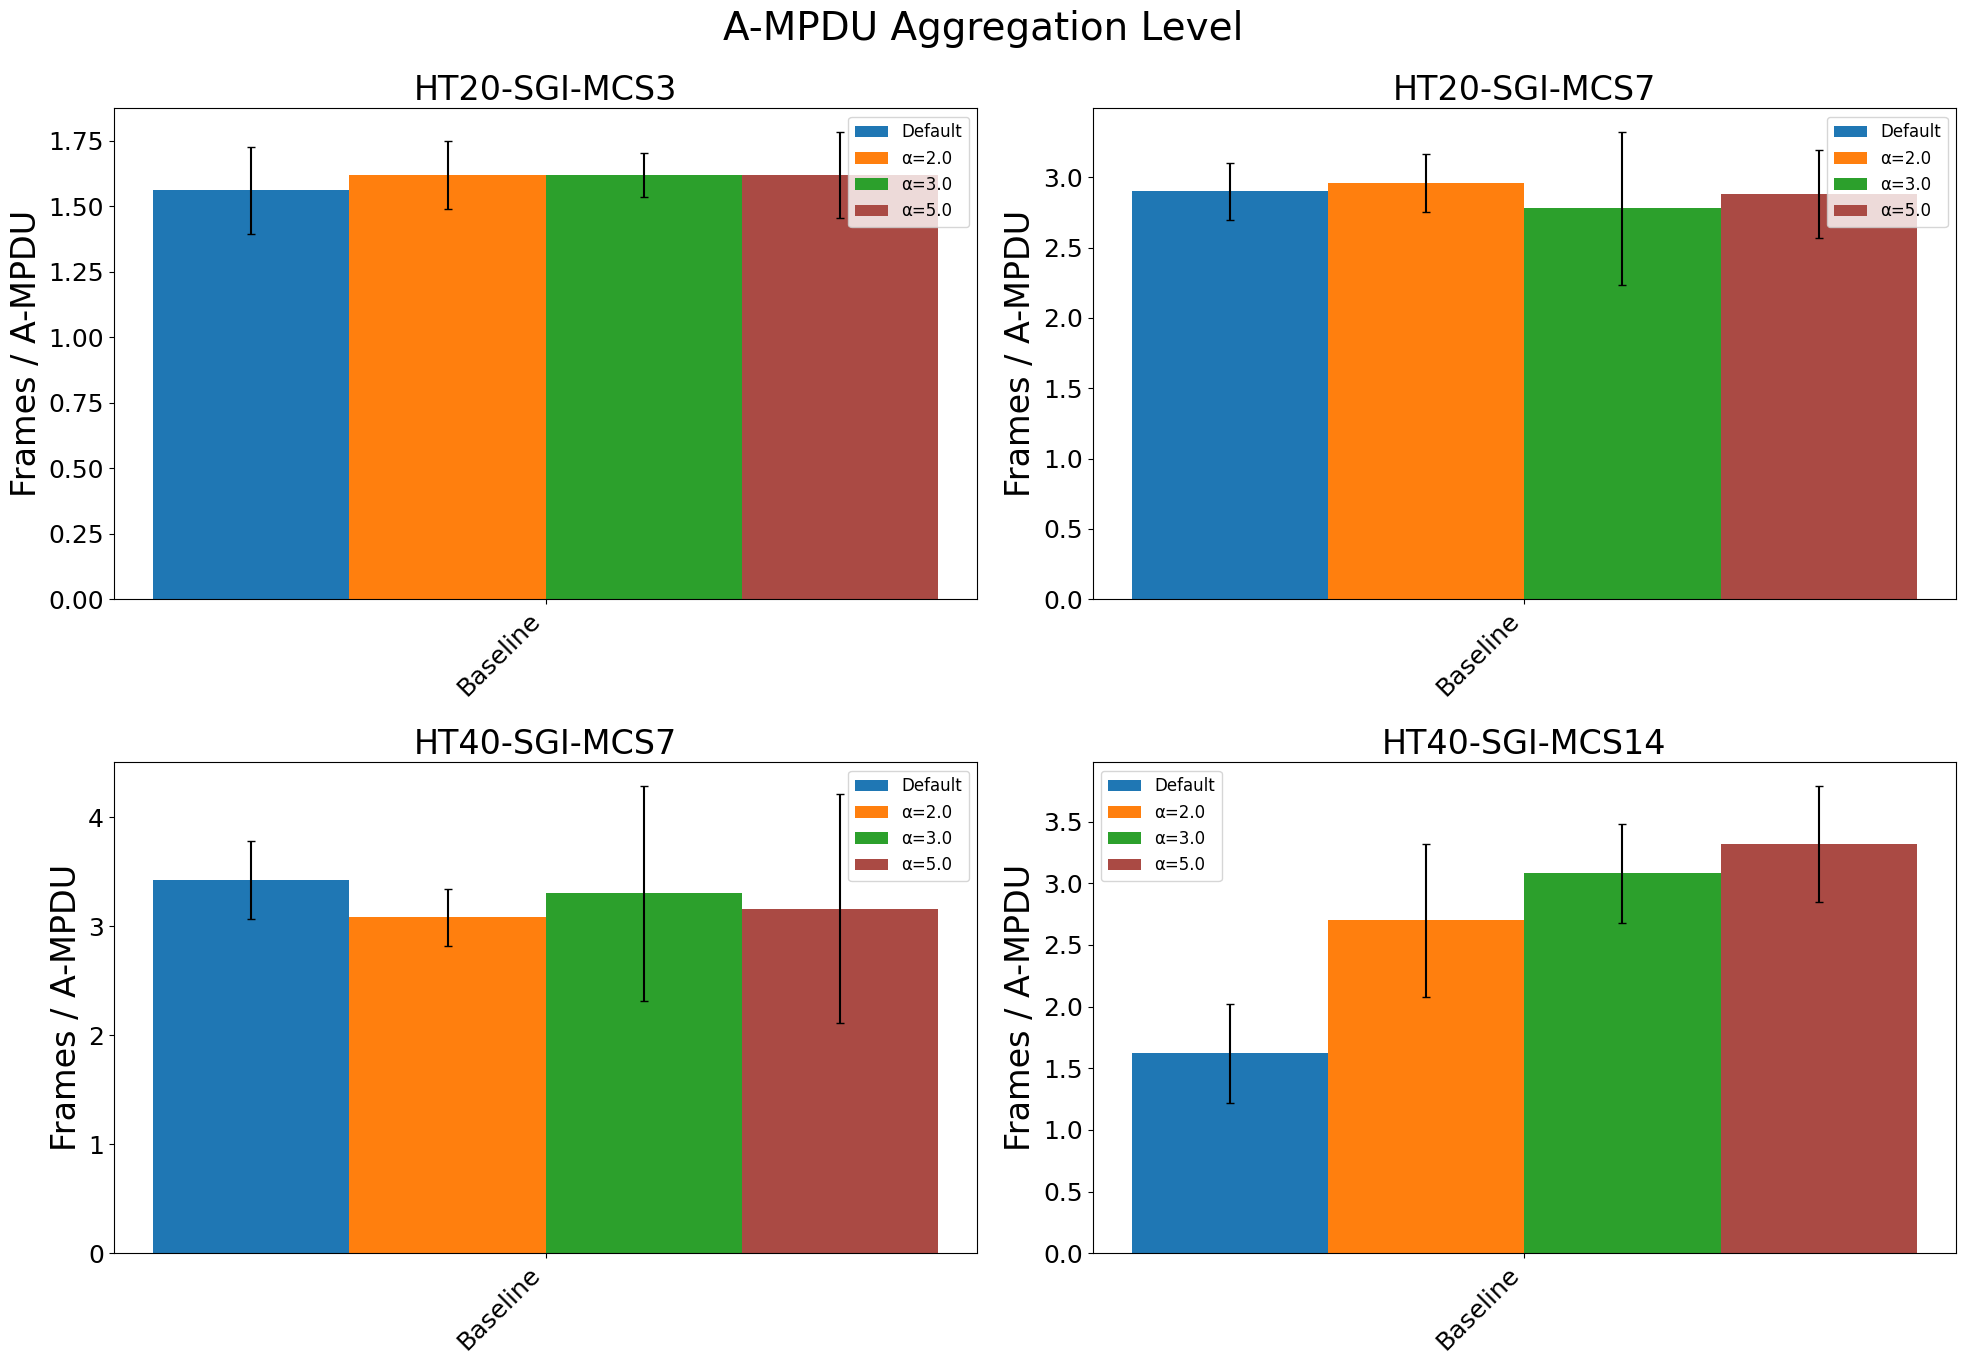

In [13]:
if not df_agg_plot.empty:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle("A-MPDU Aggregation Level")

    for ax, rate_name in zip(axes.flat, RATE_ORDER):
        rate_df = df_agg_plot[df_agg_plot["rate_name"] == rate_name]
        stats = rate_df.groupby(["condition", "kernel"])["ampdu_avg"].agg(["mean", "std"]).reset_index()

        x = np.arange(len(CONDITION_ORDER))
        width = 0.18

        for i, (kernel, label) in enumerate(KERNEL_LABELS.items()):
            ks = stats[stats["kernel"] == kernel].set_index("condition")
            means = [ks.loc[c, "mean"] if c in ks.index else 0 for c in CONDITION_ORDER]
            stds = [ks.loc[c, "std"] if c in ks.index else 0 for c in CONDITION_ORDER]
            ax.bar(x + i * width, means, width, yerr=stds, label=label, color=PLOT_COLORS[i], capsize=3)

        ax.set_title(rate_name)
        ax.set_ylabel("Frames / A-MPDU")
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right")
        ax.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(plot_dir / "router_aggregation.png", dpi=150, bbox_inches="tight")
    plt.show()

# ACK Rate (500 ms windows)

In [14]:
def load_ack_rate(cfg, kernel, rate, bw, delay, iteration):
    path = cfg.ack_rate_path(kernel, rate, bw, delay, iteration)
    rows = []
    for line in path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) == 2:
            try:
                rows.append({"ts": parts[0], "count": int(parts[1])})
            except ValueError:
                continue
    if not rows:
        return pd.DataFrame(columns=["ts", "count", "t_sec"])
    df_ar = pd.DataFrame(rows)
    df_ar["t"] = pd.to_datetime(df_ar["ts"], format="%H:%M:%S.%f")
    df_ar["t_sec"] = (df_ar["t"] - df_ar["t"].iloc[0]).dt.total_seconds()
    return df_ar[["ts", "count", "t_sec"]]


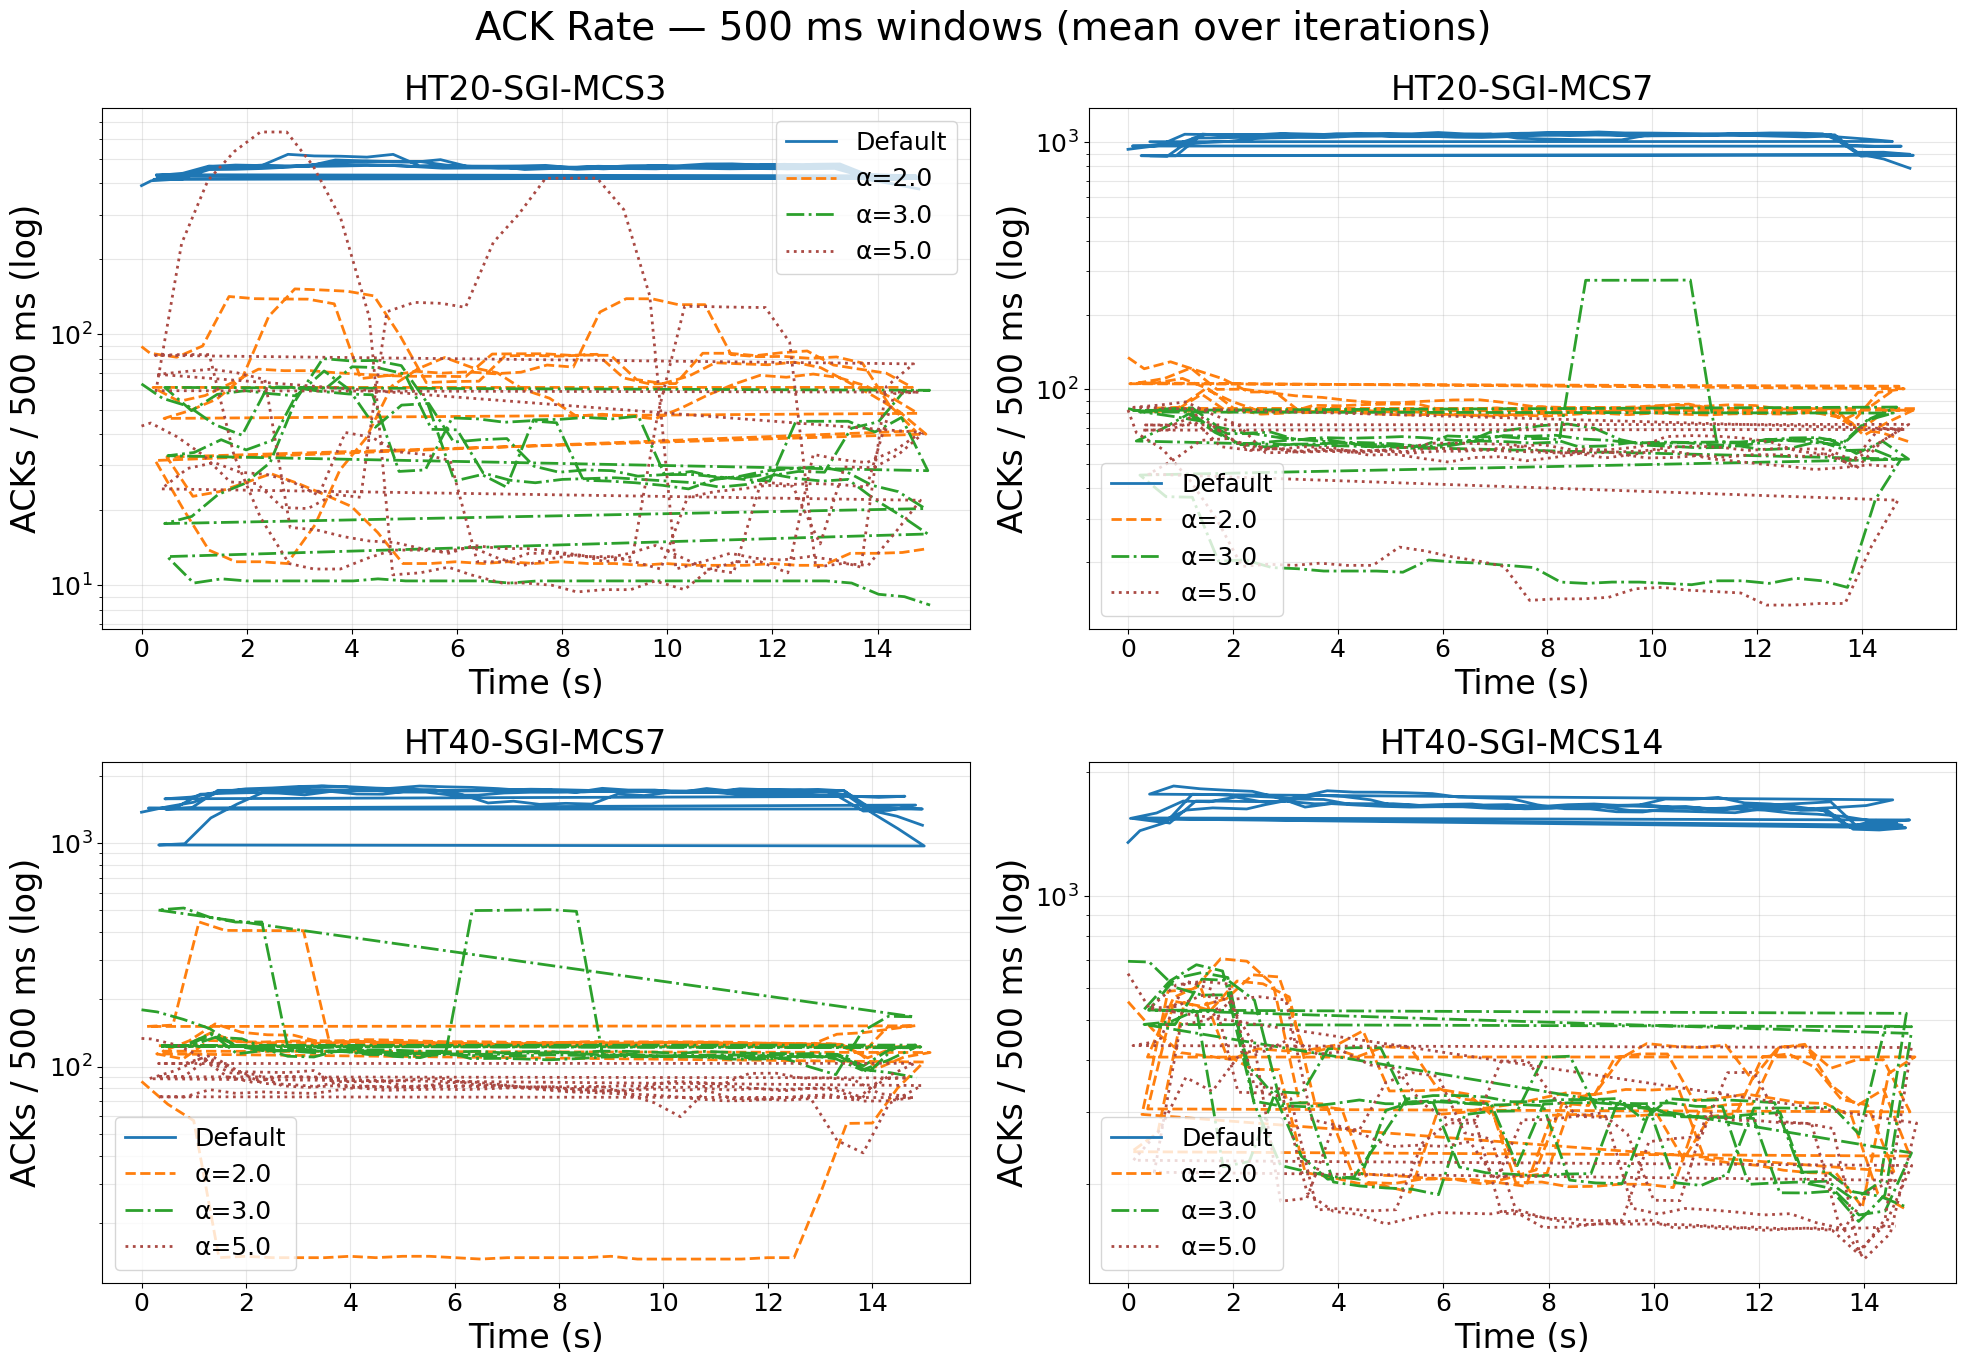

In [15]:
SMOOTH_WIN = 5  # rolling average window (~2.5 s)
LINESTYLES = ["-", "--", "-.", ":"]

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("ACK Rate — 500 ms windows (mean over iterations)")

for ax, rate in zip(axes.flat, sorted(_RATE_MAP)):
    for ci, kernel in enumerate(config.kernels):
        iters = []
        for it in range(1, config.iterations + 1):
            df_ar = load_ack_rate(config, kernel, rate, "nolim", "nodelay", it)
            if df_ar.empty:
                continue
            iters.append(df_ar.set_index("t_sec")["count"])
        if not iters:
            continue
        combined = pd.concat(iters, axis=1).mean(axis=1)
        smoothed = combined.rolling(SMOOTH_WIN, center=True, min_periods=1).mean()
        ax.plot(smoothed.index, smoothed.values,
                color=PLOT_COLORS[ci], linestyle=LINESTYLES[ci],
                linewidth=2, label=KERNEL_LABELS.get(kernel, kernel))

    ax.set_title(f"{_RATE_MAP[rate]}")
    ax.set_ylabel("ACKs / 500 ms (log)")
    ax.set_xlabel("Time (s)")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3, which="both")

fig.tight_layout()
fig.savefig(plot_dir / "router_ack_rate.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
summary_rows = []
for cfg, run_label in [(config, "dmesg"), (config_nodmesg, "nodmesg")]:
    for kernel in cfg.kernels:
        for rate in sorted(_RATE_MAP):
            counts = []
            for it in range(1, cfg.iterations + 1):
                df_ar = load_ack_rate(cfg, kernel, rate, "nolim", "nodelay", it)
                if len(df_ar) > 1:
                    counts.extend(df_ar["count"].iloc[:-1].tolist())
            if counts:
                s = pd.Series(counts)
                summary_rows.append({
                    "kernel": KERNEL_LABELS.get(kernel, kernel),
                    "run": run_label,
                    "rate_name": _RATE_MAP[rate],
                    "mean_per_500ms": round(s.mean(), 1),
                    "std": round(s.std(), 1),
                    "mean_per_s": round(s.mean() * 2, 1),
                })

df_ack_rate_summary = pd.DataFrame(summary_rows)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(df_ack_rate_summary.sort_values(["rate_name", "kernel", "run"]).reset_index(drop=True))


,kernel,run,rate_name,mean_per_500ms,std,mean_per_s
0,Default,dmesg,HT20-SGI-MCS3,460.6,50.8,921.2
1,Default,nodmesg,HT20-SGI-MCS3,488.8,49.6,977.5
2,α=2.0,dmesg,HT20-SGI-MCS3,63.1,52.4,126.1
3,α=2.0,nodmesg,HT20-SGI-MCS3,50.2,60.1,100.5
4,α=3.0,dmesg,HT20-SGI-MCS3,35.3,31.2,70.7
5,α=3.0,nodmesg,HT20-SGI-MCS3,24.6,41.2,49.2
6,α=5.0,dmesg,HT20-SGI-MCS3,66.4,168.8,132.9
7,α=5.0,nodmesg,HT20-SGI-MCS3,27.9,74.4,55.9
8,Default,dmesg,HT20-SGI-MCS7,1052.6,102.4,2105.3
9,Default,nodmesg,HT20-SGI-MCS7,1178.4,130.6,2356.7
